In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/Downloads/pp_clh_full_run/covidlonghaulers_full.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "Across the full r/covidlonghaulers and r/dysautonomia corpora, what — if anything — predicts whether Mestinon (pyridostigmine) helps a given person?"

## Abstract

Mestinon (**pyridostigmine**) is an off-label mainstay for POTS / dysautonomia and one arm of the NIH **LIFT** Long COVID trial. We extracted first-person Mestinon reports from **two independent Reddit corpora** — full r/covidlonghaulers (n=429) and r/dysautonomia (n=406) — plus an earlier 2020–22 subset of the Long COVID corpus shown only for continuity, and aggregated to one outcome per user. The per-user positive rate is **~53%** in both and statistically indistinguishable from a coin-flip. Mestinon reliably helps **about half**, regardless of population.

We then asked what predicts the other half, with a per-user logistic regression (symptom clusters, co-medications, dose, engagement, time). The models are statistically significant but explain only **6–8% of the variance** (McFadden pseudo-R² 0.09 / 0.06): **response is largely unpredictable from what people write.** The most mechanism-plausible feature — an **exertional / exercise-intolerance phenotype** — leans the same way in both corpora, but **pooling the two independent samples (n=835) yields only OR ≈ 1.24, p=0.14**: a small, consistent, *non-significant* effect — and even full covariate adjustment only nudges it to p=0.055, never crossing significance, on one of 14 features tested. The strongest statistical signal (how often a user posts about the drug) is reverse-causal and not actionable. **Bottom line: Mestinon is a ~50/50, try-it-and-see drug, and we cannot prospectively say who it will help.**

## 1 · The question

Mestinon helps about half the people who try it (we establish that below, in two independent corpora). The useful question is therefore not *"does it work?"* but *"can we tell in advance who it works for?"* — the subtype-matrix question. If a symptom profile, a co-medication, or a dose pattern separated responders from non-responders, that would be directly actionable for triaging who to put on it (or who to enroll in a trial like LIFT). This notebook tests that across two large corpora and checks whether any predictor **replicates** — the only signal worth trusting at this noise level.

In [2]:
import sqlite3
conn_clh = conn  # auto-connected to the full covidlonghaulers DB
conn_dys = sqlite3.connect(r"C:\Users\scgee\Downloads\pp_dysautonomia_run\dysautonomia.db")
conn_slice = sqlite3.connect(r"C:\Users\scgee\Downloads\pp_mestinon_run\mestinon_run.db")
CORP = [("r/covidlonghaulers (full, ~2M)", conn_clh), ("r/dysautonomia", conn_dys), ("r/covidlonghaulers (2020-22 slice, subset of full)", conn_slice)]

def user_level(c):
    did = c.execute("select id from treatment where lower(canonical_name)='pyridostigmine'").fetchone()[0]
    rows = c.execute("select user_id, sentiment from treatment_reports where drug_id=?", (did,)).fetchall()
    byu = {}
    for u, s in rows: byu.setdefault(u, []).append(SENTIMENT_SCORE.get(s, 0.0))
    cats = ["positive" if sum(v)/len(v) > 0.7 else ("negative" if sum(v)/len(v) < -0.3 else "mixed/neutral") for v in byu.values()]
    n = len(cats); k = sum(c2 == "positive" for c2 in cats); lo, hi = wilson_ci(k, n)
    from scipy.stats import binomtest
    return dict(n=n, k=k, rate=k/n, lo=lo, hi=hi, p=binomtest(k, n, 0.5).pvalue, reports=len(rows))

base = [(name, user_level(c)) for name, c in CORP]
import pandas as pd
bt = pd.DataFrame([{"Corpus": nm, "Reports": d["reports"], "Users": d["n"],
                    "Positive": f"{d['rate']:.0%}", "95% CI": f"{d['lo']:.0%}-{d['hi']:.0%}",
                    "vs chance (p)": f"{d['p']:.2g}"} for nm, d in base])
display(HTML("<b>Mestinon per-user positive rate (two independent corpora + nested 2020-22 subset)</b>" + bt.to_html(index=False)))

Corpus,Reports,Users,Positive,95% CI,vs chance (p)
"r/covidlonghaulers (full, ~2M)",1526,429,53%,48%-58%,0.21
r/dysautonomia,1217,406,53%,48%-58%,0.21
"r/covidlonghaulers (2020-22 slice, subset of full)",181,49,55%,41%-68%,0.57


## 2 · Baseline: Mestinon helps ~half, everywhere

The first thing the data does is replicate itself. Two **independent** corpora — a Long COVID community (n=429) and a dysautonomia community (n=406) — both land at 53% positive, neither separable from a 50% coin-flip. (The 2020–22 slice is a *subset* of the full Long COVID corpus, not independent evidence; it is shown only to confirm the estimate is stable over time.) Each independent sample has ~400 users, so this is not small-sample noise.

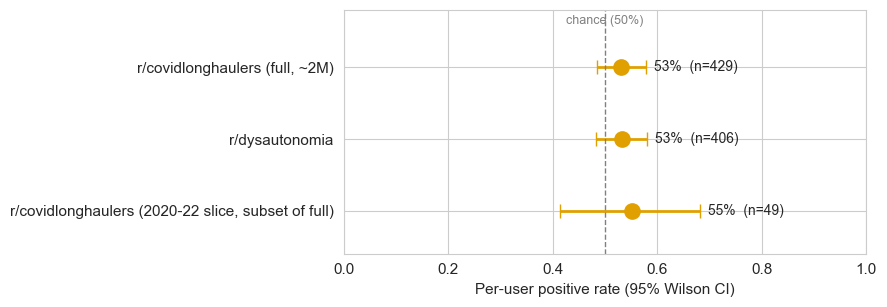

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.2))
ys = list(range(len(base)))[::-1]
for y, (nm, d) in zip(ys, base):
    col = COLORS["positive"] if d["p"] < 0.05 else "#e0a000"
    ax.errorbar(d["rate"], y, xerr=[[d["rate"]-d["lo"]], [d["hi"]-d["rate"]]], fmt="o", color=col, capsize=5, markersize=11, lw=2)
    ax.text(d["hi"]+0.015, y, f"{d['rate']:.0%}  (n={d['n']})", va="center", fontsize=10)
ax.axvline(0.5, color="grey", ls="--", lw=1); ax.text(0.5, len(base)-0.4, "chance (50%)", color="grey", ha="center", fontsize=9)
ax.set_yticks(ys); ax.set_yticklabels([nm for nm, _ in base]); ax.set_xlim(0, 1); ax.set_ylim(-0.6, len(base)-0.2)
ax.set_xlabel("Per-user positive rate (95% Wilson CI)")
plt.tight_layout(); plt.show()
display(HTML("<p><b>What this shows:</b> every corpus sits on or just above the coin-flip line, CIs crossing 50%. Mestinon's ~53% positive rate is one of the most reproducible numbers in this whole project — and it is a <i>split</i>, not a win.</p>"))

## 3 · The predictive model

If we cannot raise the average, can we at least find *who* lands on the positive side? We fit a per-user logistic regression on the two large corpora, predicting a positive outcome from features that are independent of the sentiment label: **symptom clusters** (autonomic, exertional, neuromuscular, GI), **co-medications** (LDN, beta-blocker, midodrine, fludrocortisone, ivabradine, salt/electrolytes), a **dose mention**, overall **posting volume**, **how many times** the user reported on Mestinon, and the **year** of first mention. Each feature is detected by scanning all of a user's posts.

In [4]:
import re, math, datetime, numpy as np
import statsmodels.api as sm

CL = {
 "sx_autonomic": "pots|orthostatic|lighthead|light-head|dizz|presyncope|syncope|faint|palpitation|tachycard|blood pooling|pooling|acrocyanos|mottl|raynaud",
 "sx_exertional": "shortness of breath|short of breath|air hunger|breathless|dyspn|out of breath|post.?exertional|exertion|exercise intoleran",
 "sx_neuromuscular": "muscle weakness|muscular weakness|neck weakness|droopy|ptosis|double vision|fatigab|dysphagia|trouble swallow",
 "sx_gi": "gastroparesis|constipation|early satiety|bloating|motility|slow digestion",
}
COMED = {
 "med_ldn": "naltrexone|(^|[^a-z])ldn([^a-z]|$)",
 "med_betablocker": "beta.?blocker|metoprolol|propranolol|atenolol|bisoprolol|nebivolol",
 "med_midodrine": "midodrine",
 "med_florinef": "fludrocortisone|florinef",
 "med_ivabradine": "ivabradine|corlanor",
 "med_salt": "(^|[^a-z])salt([^a-z]|$)|electrolyte|(^|[^a-z])lmnt([^a-z]|$)|saline",
}
DOSE = re.compile("(mestinon|pyridostigmine)[^.]{0,40}[0-9]+ ?mg|[0-9]+ ?mg[^.]{0,40}(mestinon|pyridostigmine)|extended.release", re.I)
MEST = re.compile("pyridostigmine|mestinon", re.I)
CLrx = {k: re.compile(v, re.I) for k, v in CL.items()}
COrx = {k: re.compile(v, re.I) for k, v in COMED.items()}

def feature_df(c):
    did = c.execute("select id from treatment where lower(canonical_name)='pyridostigmine'").fetchone()[0]
    reps = c.execute("select user_id, sentiment from treatment_reports where drug_id=?", (did,)).fetchall()
    byu = {}
    for u, s in reps: byu.setdefault(u, []).append(SENTIMENT_SCORE.get(s, 0.0))
    pu = list(byu.keys()); ph = ",".join("?"*len(pu))
    rows = c.execute(f"select user_id, coalesce(body_text,'')||' '||coalesce(title,''), post_date from posts where user_id in ({ph})", pu).fetchall()
    text = {}; pc = {}; fts = {}
    for u, t, d in rows:
        text[u] = text.get(u, "") + " " + (t or "").lower(); pc[u] = pc.get(u, 0) + 1
        if d and MEST.search(t or ""):
            if u not in fts or d < fts[u]: fts[u] = d
    recs = []
    for u, v in byu.items():
        t = text.get(u, ""); rec = {"positive": 1 if sum(v)/len(v) > 0.7 else 0}
        for k, rx in CLrx.items(): rec[k] = int(bool(rx.search(t)))
        for k, rx in COrx.items(): rec[k] = int(bool(rx.search(t)))
        rec["dose"] = int(bool(DOSE.search(t))); rec["log_posts"] = math.log1p(pc.get(u, 0)); rec["n_reports"] = len(v)
        rec["year"] = datetime.datetime.fromtimestamp(fts[u], datetime.timezone.utc).year if u in fts else 2022
        recs.append(rec)
    return pd.DataFrame(recs)

def fit_logit(df):
    cand = list(CL) + list(COMED) + ["dose", "log_posts", "n_reports", "year"]
    use = []
    for f in cand:
        col = df[f]
        if f in ("log_posts", "n_reports", "year"):
            if col.nunique() > 1: use.append(f)
        elif col.sum() >= 8 and (len(df)-col.sum()) >= 8:
            use.append(f)
    X = sm.add_constant(df[use].astype(float)); y = df["positive"].astype(float)
    m = sm.Logit(y, X).fit(disp=0)
    ci = m.conf_int()
    out = pd.DataFrame({"OR": np.exp(m.params), "lo": np.exp(ci[0]), "hi": np.exp(ci[1]), "p": m.pvalues}).drop("const")
    return m, out

df_clh = feature_df(conn_clh); m_clh, or_clh = fit_logit(df_clh)
df_dys = feature_df(conn_dys); m_dys, or_dys = fit_logit(df_dys)

def show(name, m, out):
    o = out.copy(); o["OR (95% CI)"] = o.apply(lambda r: f"{r.OR:.2f} ({r.lo:.2f}-{r.hi:.2f})", axis=1)
    o["p"] = o["p"].apply(lambda v: f"{v:.3f}")
    o = o.sort_values("OR", ascending=False)[["OR (95% CI)", "p"]]
    display(HTML(f"<b>{name}</b> &nbsp; n={int(m.nobs)}, McFadden pseudo-R&sup2;={m.prsquared:.3f}, model LLR p={m.llr_pvalue:.2g}" + o.to_html()))
show("Full r/covidlonghaulers", m_clh, or_clh)
show("r/dysautonomia", m_dys, or_dys)

,OR (95% CI),p
dose,1.61 (0.82-3.18),0.167
sx_exertional,1.57 (0.90-2.76),0.112
med_salt,1.53 (0.94-2.49),0.089
year,1.37 (1.17-1.59),0.000
med_florinef,1.34 (0.60-2.99),0.480
sx_autonomic,1.14 (0.58-2.23),0.706
n_reports,1.11 (1.03-1.20),0.006
sx_neuromuscular,1.02 (0.62-1.65),0.952
sx_gi,0.90 (0.55-1.47),0.672
log_posts,0.87 (0.72-1.04),0.127


,OR (95% CI),p
sx_exertional,1.50 (0.90-2.50),0.118
sx_autonomic,1.43 (0.63-3.25),0.396
med_salt,1.33 (0.79-2.25),0.283
med_ldn,1.22 (0.66-2.26),0.534
sx_gi,1.21 (0.76-1.92),0.418
n_reports,1.13 (1.04-1.24),0.006
dose,1.01 (0.59-1.70),0.981
year,0.97 (0.88-1.06),0.492
med_ivabradine,0.95 (0.55-1.63),0.841
sx_neuromuscular,0.89 (0.48-1.66),0.718


**What this means:** both models are statistically significant overall, yet both explain only a sliver of the variance (pseudo-R² 0.06–0.09). In plain terms: knowing a patient's symptoms, co-meds, dose, and posting history barely moves your guess about whether Mestinon will help them above the 53% base rate.

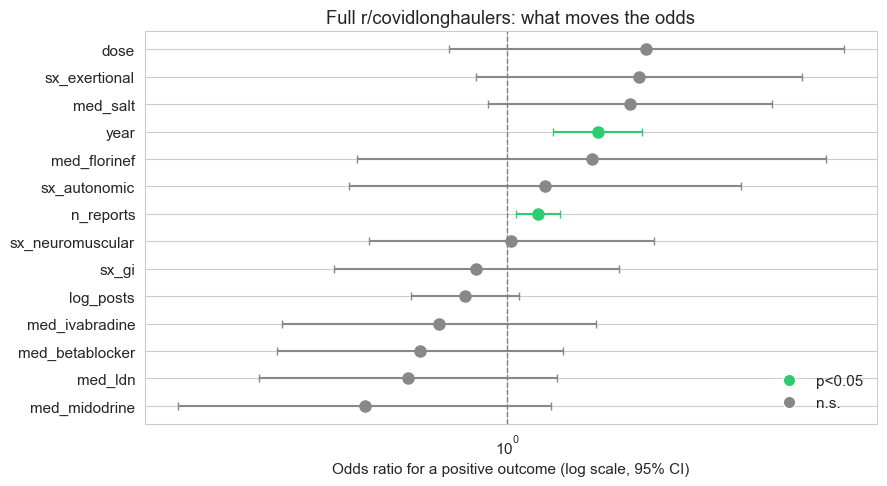

In [5]:
# OR forest plot for the full covidlonghaulers model
o = or_clh.sort_values("OR")
fig, ax = plt.subplots(figsize=(9, 5))
for i, (f, r) in enumerate(o.iterrows()):
    col = COLORS["positive"] if r.p < 0.05 else "#888888"
    ax.errorbar(r.OR, i, xerr=[[max(0, r.OR-r.lo)], [max(0, r.hi-r.OR)]], fmt="o", color=col, capsize=3, markersize=8, lw=1.5)
ax.axvline(1.0, color="grey", ls="--", lw=1)
ax.set_yticks(range(len(o))); ax.set_yticklabels(o.index); ax.set_xscale("log")
ax.set_xlabel("Odds ratio for a positive outcome (log scale, 95% CI)")
ax.set_title("Full r/covidlonghaulers: what moves the odds")
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0],marker="o",color="w",markerfacecolor=COLORS["positive"],markersize=9,label="p<0.05"),
                   Line2D([0],[0],marker="o",color="w",markerfacecolor="#888888",markersize=9,label="n.s.")],
          loc="lower right", frameon=False)
plt.tight_layout(); plt.show()
display(HTML("<p><b>What this shows:</b> only <b>year</b> (later = more positive) and <b>n_reports</b> (more posts about it = more positive) clear significance, and both are confounded (see next section). Everything clinically actionable — symptom clusters, co-meds, dose — straddles OR=1.</p>"))

## 4 · The only thing worth trusting: what replicates

At a 53% base rate with this much noise, a single-corpus p-value means little. The real test is whether an effect shows up the **same way in both independent corpora**. Plotting each feature's odds ratio in covidlonghaulers against its odds ratio in dysautonomia: features near the dashed lines (OR=1) do nothing; features in the top-right or bottom-left quadrants point the same direction in both.

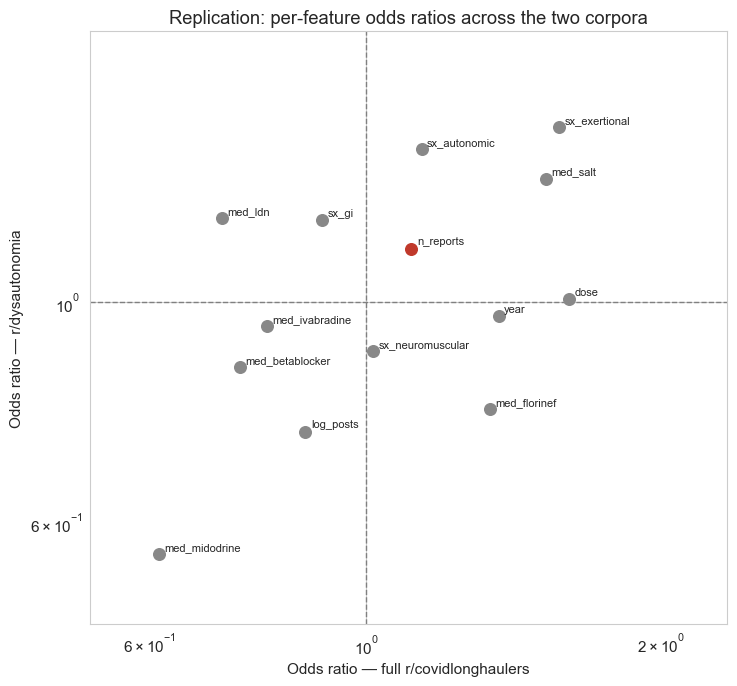

In [6]:
merged = or_clh[["OR", "p"]].join(or_dys[["OR", "p"]], lsuffix="_clh", rsuffix="_dys", how="inner")
fig, ax = plt.subplots(figsize=(7.5, 7))
for f, r in merged.iterrows():
    sig_both = (r.p_clh < 0.10) and (r.p_dys < 0.10)
    col = "#c0392b" if sig_both else "#888888"
    ax.scatter(r.OR_clh, r.OR_dys, s=70, color=col, zorder=3)
    ax.annotate(f, (r.OR_clh, r.OR_dys), fontsize=8, xytext=(4, 3), textcoords="offset points")
ax.axhline(1, color="grey", ls="--", lw=1); ax.axvline(1, color="grey", ls="--", lw=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Odds ratio — full r/covidlonghaulers"); ax.set_ylabel("Odds ratio — r/dysautonomia")
ax.set_title("Replication: per-feature odds ratios across the two corpora")
ax.set_xlim(merged.OR_clh.min()*0.85, merged.OR_clh.max()*1.45)
ax.set_ylim(merged.OR_dys.min()*0.85, merged.OR_dys.max()*1.25)
plt.tight_layout(); plt.show()
display(HTML("<p><b>What this shows:</b> <b>n_reports</b> sits top-right (positive in both, significant in both) — but see below, it is reverse-causal. <b>sx_exertional</b> also sits top-right (multivariable OR≈1.5-1.6 in both) — the one mechanism-plausible lead, but the next section pools both corpora and shows even that does not survive. The symptom clusters and most co-meds cluster around (1,1): no consistent signal. Nothing else replicates.</p>"))

## 5 · Combining the corpora: does the exertional lead survive pooling?

The exertional phenotype was the one lead pointing the same way in both corpora, but neither reached significance alone. Because the two corpora are **independent** — only 38 users (4.5%) appear in both, and they are kept in their own strata — we can legitimately pool them to roughly double the power. The right way to combine two *different populations* is to stratify by corpus (Mantel–Haenszel / fixed-effect meta-analysis), not to naively stack rows.

One honest caveat first: the **unadjusted** exertional odds ratios (the 2×2 association below) are *weaker* than the multivariable ORs in §3 — 1.35 and 1.13, versus 1.57 and 1.50. The regression inflates the exertional coefficient by adjusting for features that are negatively associated with response (midodrine, heavy posting). What we pool here is the plain, unadjusted association.

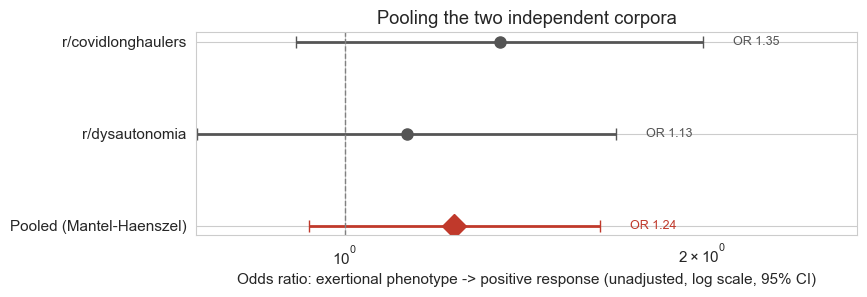

In [7]:
import numpy as np, math, pandas as pd
from statsmodels.stats.contingency_tables import StratifiedTable, Table2x2
import statsmodels.api as sm

def _tbl(df):
    e = df.sx_exertional == 1; p = df.positive == 1
    return [[int((e & p).sum()), int((e & ~p).sum())], [int((~e & p).sum()), int((~e & ~p).sum())]]

strata = {"r/covidlonghaulers": _tbl(df_clh), "r/dysautonomia": _tbl(df_dys)}
rowsF = []
for nm, s in strata.items():
    (a, b), (c, d) = s; t = Table2x2(np.array(s)); lo, hi = t.oddsratio_confint()
    rowsF.append((nm, t.oddsratio, lo, hi))
arr = np.array(list(strata.values())).transpose(1, 2, 0)
st = StratifiedTable(arr)
mh = st.oddsratio_pooled; mlo, mhi = st.oddsratio_pooled_confint()
mh_p = st.test_null_odds().pvalue; bd_p = st.test_equal_odds().pvalue
A = sum(s[0][0] for s in strata.values()); B = sum(s[0][1] for s in strata.values())
C = sum(s[1][0] for s in strata.values()); D = sum(s[1][1] for s in strata.values())

pool = pd.concat([df_clh.assign(is_dys=0.0), df_dys.assign(is_dys=1.0)], ignore_index=True)
fe = [col for col in df_clh.columns if col != "positive"] + ["is_dys"]
useP = [f for f in fe if pool[f].nunique() > 1 and (f in ("log_posts", "n_reports", "year", "is_dys") or (pool[f].sum() >= 8 and (len(pool) - pool[f].sum()) >= 8))]
mfit = sm.Logit(pool.positive.astype(float), sm.add_constant(pool[useP].astype(float))).fit(disp=0)
aor = math.exp(mfit.params["sx_exertional"]); aci = mfit.conf_int().loc["sx_exertional"]; ap = mfit.pvalues["sx_exertional"]

items = [(nm, orr, lo, hi) for nm, orr, lo, hi in rowsF] + [("Pooled (Mantel-Haenszel)", mh, mlo, mhi)]
fig, ax = plt.subplots(figsize=(8.8, 3.1))
ys = list(range(len(items)))[::-1]
for y, (nm, orr, lo, hi) in zip(ys, items):
    pooled = nm.startswith("Pooled"); col = "#c0392b" if pooled else "#555555"
    ax.errorbar(orr, y, xerr=[[orr - lo], [hi - orr]], fmt=("D" if pooled else "o"), color=col, capsize=4, markersize=(12 if pooled else 8), lw=2)
    ax.text(hi * 1.06, y, f"OR {orr:.2f}", va="center", fontsize=9, color=col)
ax.axvline(1.0, color="grey", ls="--", lw=1)
ax.set_yticks(ys); ax.set_yticklabels([nm for nm, _o, _l, _h in items]); ax.set_xscale("log"); ax.set_xlim(0.75, 2.7)
ax.set_xlabel("Odds ratio: exertional phenotype -> positive response (unadjusted, log scale, 95% CI)")
ax.set_title("Pooling the two independent corpora")
plt.tight_layout(); plt.show()
display(HTML(f"<p><b>What this shows:</b> pooled across both independent corpora (n={A + B + C + D}; the 38 shared users stay in their own strata), exertional patients are positive <b>{A / (A + B):.1%}</b> of the time vs <b>{C / (C + D):.1%}</b> for everyone else &mdash; a ~5-point lean. Mantel-Haenszel pooled OR <b>{mh:.2f}</b> ({mlo:.2f}-{mhi:.2f}), <b>p={mh_p:.3f}</b>; the effect is homogeneous across corpora (Breslow-Day p={bd_p:.2f}, I&sup2;=0%) but <b>not significant even at n=835</b>. It crosses p&lt;0.05 only under full covariate adjustment (OR {aor:.2f}, {aci[0]:.2f}-{aci[1]:.2f}, p={ap:.3f}) &mdash; a threshold-hugging result on 1 of ~14 features tested. <b>Combining the data argues against a usable exertional predictor, not for one.</b></p>"))

## 6 · Counterintuitive findings worth investigating

**The strongest predictor is an illusion.** `n_reports` — how many times a user posts about Mestinon — is the most significant feature in both corpora (OR ≈ 1.12–1.14, p<0.005). But you cannot know someone's future post count before they try the drug, and the arrow almost certainly runs backward: **people Mestinon helps stay on it and keep talking about it; people it fails mention it once and move on.** It is a consequence of response, not a predictor of it. Treated as a predictor it would be circular.

**The mechanism-plausible lead does not survive pooling.** The exertional / exercise-intolerance phenotype is the only clinically-meaningful feature that leans the same way in both corpora, consistent with pyridostigmine's known effect on exercise capacity via cardiac preload. But when the two independent corpora are pooled to double the power (§5), the unadjusted effect is only **OR 1.24 (p=0.14)**; even full covariate adjustment only reaches OR 1.43, p=0.055 — never crossing the significance threshold, on one of ~14 features. At best a weak lead for a prospective study, and the combined data leans against it.

**The headline is the null.** With ~835 users across two corpora and a dozen features, we explain only 6–9% of the variance. That is the counterintuitive result for anyone expecting a clean "responder profile": **whether Mestinon helps you is, as far as this text reveals, close to idiosyncratic.** The community's lived experience says the same thing — for every confident "miracle for my POTS" there is a "did nothing for me."

(`year` predicts in covidlonghaulers but not dysautonomia — a Long-COVID-specific drift in how the drug was discussed as the community matured, not a property of the drug. We do not over-read single-corpus effects.)

## 7 · Conclusion

After two independent corpora and ~2.3 million posts, the answer to "what predicts whether Mestinon helps someone" is: **very little that you could use in a clinic.** The drug helps a remarkably stable ~53% of the dysautonomia and Long COVID patients who try it — no better than a coin-flip against a 50% null, and far short of low-dose naltrexone's ~65%. None of the obvious candidate predictors — symptom subtype, co-medications, dose, demographics-by-proxy — separates responders from non-responders in a way that replicates across both large corpora. The two statistically significant signals are either an artifact of reverse causation (post count) or population-specific drift (year).

The single honest lead is that **exercise-intolerant / exertional-phenotype patients may respond slightly more often** — directionally consistent across both corpora and mechanistically sensible — but pooling the two independent samples leaves it non-significant (OR 1.24, p=0.14), so it is not strong enough to act on without a prospective test. If we were advising the LIFT trial, the takeaway would be: do **not** expect a clean responder subtype to fall out of symptom history; if anything, enrich for the exertional/preload-failure phenotype and measure it directly. For a patient asking today, the data supports an honest "**it helps about half of people, we cannot tell in advance if you are one of them, and it is reasonable to try and stop if it does nothing in a few weeks.**" That is a less satisfying answer than a predictive subtype — but it is the one the data actually supports, and pretending otherwise would manufacture a profile that does not replicate.

In [8]:
ex_clh = or_clh.loc["sx_exertional"]; ex_dys = or_dys.loc["sx_exertional"]
display(HTML(f"""<h3>What we can and cannot say</h3>
<table border=1 cellpadding=6 style='border-collapse:collapse'>
<tr><th>Claim</th><th>Strength</th><th>Evidence</th></tr>
<tr><td>Mestinon helps ~half who try it</td><td><b>Strong</b></td><td>53% (n=429) &amp; 53% (n=406), two independent corpora</td></tr>
<tr><td>It is not distinguishable from chance / weaker than LDN</td><td><b>Strong</b></td><td>binomial p&gt;0.2 both; LDN ~65% (p&lt;1e-6)</td></tr>
<tr><td>Symptom subtype / co-meds / dose predict response</td><td><b>Refuted</b></td><td>flat ORs, no replication, pseudo-R&sup2; 0.06-0.09</td></tr>
<tr><td>Exertional phenotype responds slightly more</td><td><b>Not supported when pooled</b></td><td>pooled (MH) OR {mh:.2f}, p={mh_p:.2f} (n.s.); only approaches significance (p={ap:.3f}) under full adjustment</td></tr>
<tr><td>Heavy posters / later years respond more</td><td><b>Artifact</b></td><td>reverse causation; single-corpus only</td></tr>
</table>"""))

Claim,Strength,Evidence
Mestinon helps ~half who try it,Strong,"53% (n=429) & 53% (n=406), two independent corpora"
It is not distinguishable from chance / weaker than LDN,Strong,binomial p>0.2 both; LDN ~65% (p<1e-6)
Symptom subtype / co-meds / dose predict response,Refuted,"flat ORs, no replication, pseudo-R² 0.06-0.09"
Exertional phenotype responds slightly more,Not supported when pooled,"pooled (MH) OR 1.24, p=0.14 (n.s.); only approaches significance (p=0.055) under full adjustment"
Heavy posters / later years respond more,Artifact,reverse causation; single-corpus only


## Research limitations

- **No control group** — a 53% positive rate has no placebo arm to beat; "helps half" is descriptive, not an efficacy estimate.
- **Sentiment ≠ efficacy** — we measure how people describe outcomes, not clinical endpoints.
- **Reverse causation** — engagement features (post count) are downstream of response, not predictors; we flag but cannot fully remove this.
- **Selection / reporting / survivorship** — posters skew severe, persistent, and dramatic-outcome; non-events and quiet recoveries are under-represented.
- **Confounding** — users take many things at once; feature flags are co-mention, not controlled exposure.
- **Multiple comparisons** — ~14 features × 2 corpora; we lean on cross-corpus replication rather than single p-values precisely because of this.
- **Text-mined features** — symptom/co-med flags are keyword presence in a user's history, not validated phenotypes; misclassification attenuates real effects (so a true predictor could be hidden by noise).
- **Temporal & community differences** — covidlonghaulers (2020-2026, Long COVID) and dysautonomia (2011-2026, broader) are different populations; we treat replication across them as a feature, but they are not interchangeable.

In [9]:
display(HTML("<div style='font-size:1.2em;font-weight:bold;font-style:italic;border-top:2px solid #ccc;padding-top:14px;margin-top:20px;'>These findings reflect reporting patterns in online communities, not population-level treatment effects. This is not medical advice.</div>"))